# Umfangreiche Analyse von Aktien

## 1. Import der Module

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pltma
import yfinance as yf
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator # ermöglicht es, zusätzliche Teilstriche (Ticks) zwischen den Hauptteilstrichen

## 2. Einlesen der Daten

In [2]:
START_DATE = "2018-01-01"
END_DATE = "2024-10-17"

df = yf.download("AAPL", start=START_DATE, end=END_DATE)
df.head()

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-01-02,42.540001,43.075001,42.314999,43.064999,40.568928,102223600
2018-01-03,43.132500,43.637501,42.990002,43.057499,40.561863,118071600
2018-01-04,43.134998,43.367500,43.020000,43.257500,40.750271,89738400
2018-01-05,43.360001,43.842499,43.262501,43.750000,41.214237,94640000
2018-01-08,43.587502,43.902500,43.482498,43.587502,41.061150,82271200


In [3]:
# Einige Informationen der Daten:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1709 entries, 2018-01-02 to 2024-10-16
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1709 non-null   float64
 1   High       1709 non-null   float64
 2   Low        1709 non-null   float64
 3   Close      1709 non-null   float64
 4   Adj Close  1709 non-null   float64
 5   Volume     1709 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 93.5 KB


## 3. Berechnung des gleitenden Durchschnitts

Ein gleitender Durchschnitt (englisch Moving Average, `MA`) ist ein technischer Indikator, der verwendet wird, um Preisdaten zu glätten und Trends in einem Datensatz hervorzuheben.
</br>
</br>
Ein gleitender Durchschnitt berechnet den Mittelwert aus einer festen Anzahl von Datenpunkten. Wenn neue Daten hinzukommen, wird der älteste Wert weggelassen, und der neueste Wert wird hinzugefügt. Auf diese Weise "gleitet" der Durchschnitt über den Datensatz und passt sich kontinuierlich an die aktuellsten Daten an.
</br>
</br>
Es gibt verschiedene Arten von gleitenden Durchschnitten, wie zum Beispiel:
- SMA: Simple Moving Average (einfacher gleitender Durchschnitt)
- EMA: Exponential Moving Average (exponentieller gleitender Durchschnitt)
- WMA: Weighted Moving Average (gewichteter gleitender Durchschnitt)

**Manuelle Berechnung des einfachen gleitenden Durchschnitts (SMA)**

Der einfache gleitende Durchschnitt über einen Zeitraum von $n$ Tagen wird berechnet als:

$$\text{SMA}_t=\frac{1}{n}\sum^{n-1}_{i=0}{P_{t-i}}$$

wobei:
- $t$ der aktuelle Zeitpunkt oder die aktuelle Periode ist.
- $\text{SMA}_t$ der gleitende Durchschnitt am Tag $t$ ist.
- $n$ die Anzahl der Zeitperioden (z.B. $50$ oder $200$ Tage).
- $P_{t-i}$ der Preis am Tag $t-i$ ist.


Wie genau funktioniert diese Formel?
</br>
</br>
Die Summe $\sum^{n-1}_{i=0}{P_{t-i}}$ bedeutet, dass man die Preise der aktuellen und der vorherigen $n-1$ Perioden addiert werden. So funktioniert $i$ in dieser Summe:
- Wenn $i=0$ dann $P_{t-0}=P_t$: Preis zum aktuellen Zeitpunkt
- Wenn $i=1$ dann $P_{t-1}$: Preis eine Periode vor $t$
- Wenn $i=2$ dann $P_{t-2}$: Preis zwei Perioden vor $t$
- Wenn $i=n-1$ dann $P_{t-(n-1)}$: Preis $n-1$ Perioden vor $t$

Angenommen man möchte den 5-Tages-SMA für den heutigen Tag (Tag $t$) berechnen und man hat folgende Schlusskurse:
- Tag $t$ bzw. $P_t$: 150€
- Tag $t-1$ bzw. $P_{t-1}$: 152€
- Tag $t-2$ bzw. $P_{t-2}$: 149€
- Tag $t-3$ bzw. $P_{t-3}$: 151€
- Tag $t-4$ bzw. $P_{t-4}$: 148€

Der 5-Tage-SMA berechnet sich wie folgt:
$$\text{SMA}_t=\frac{1}{5}\cdot(P_t + P_{t-1} + P_{t-2} + P_{t-3} + P_{t-4})$$
Einsetzen der Zahlenwerte liefert:
$$\text{SMA}_t=\frac{1}{5}\cdot(150+152+149+151+148)=\frac{1}{5}\cdot750=150€$$
Dabei ist:
- $n=5$ da wir einen 5-Tage-Durchschnitt berechnet haben
- $i$ läuft von $0$ bis $4$, also insgesamt 5 Werte

Diese Berechnung soll nun mit NumPy implementiert werden.


In [4]:
# Erstelle nvon Beispieldaten:
data = np.array([150, 152, 149, 151, 148])

# Festlegen, über welchen Zeitraum der SMA berechnet werden soll:
n = 5

# Leerer Array um berechnete SMA-Werte später zu speichern:
sma = np.zeros(len(data) - n + 1) # In diesen Beispiel 5 - 5 + 1 = 1 (Ein SMA Wert wird berechnet)

In [5]:
# Berechnung des SMA:
for i in range(len(sma)):
    # Berechnen des Durchschnitts über bestimmte Daten (Slicing-Operator verwenden)
    mean_specific_data = np.mean(data[i : i + n]) 
    sma[i] = mean_specific_data

In [6]:
print(f"Einfacher gleitender Durchschnitt (SMA) über {n} Tage: {sma}")

Einfacher gleitender Durchschnitt (SMA) über 5 Tage: [150.]


Wir wollen den Code für den SMA nun als Funktion haben:

In [7]:
def calculate_sma(data, period):
    sma = np.zeros(len(data) - period + 1)
    for i in range(len(sma)):
        mean_specific_data = np.mean(data[i : i + period]) 
        sma[i] = mean_specific_data
    return sma

In [8]:
# Testen der Funktion:
sma = calculate_sma(data=data, period=5)
print(sma)

[150.]


Jetzt können wir den SMA der Apple Aktie mit echten Daten berechnen. Dazu können wir unterschiedliche Zeiträume wählen, z.B. der letzten 50 Tage:

In [9]:
period = 50
sma_values  = calculate_sma(data=df["Close"], period=period)
print(sma_values )


[ 43.08014999  43.11209999  43.14105003 ... 223.66660034 224.15820038
 224.64920044]


Auffüllen von `sma_values` mit `NaN`, um die Länge anzupassen. Denn die `calculate_sma` Funktion gibt einen kürzeren Array zurück:

In [10]:
sma_padded = np.concatenate(( [np.nan]*(period -1), sma_values ))

Hinzufügen der SMA-Werte zum DataFrame:

In [11]:
df['SMA_50'] = sma_padded

Die Einträge überprüfen:

In [12]:
df[["Close", "SMA_50"]]

,Close,SMA_50
Date,,
2018-01-02,43.064999,NaN
2018-01-03,43.057499,NaN
2018-01-04,43.257500,NaN
2018-01-05,43.750000,NaN
2018-01-08,43.587502,NaN
...,...,...
2024-10-10,229.039993,223.2540
2024-10-11,227.550003,223.4378
2024-10-14,231.300003,223.6666


Warum sind SMA-Werte für mehr als die letzten 50 Tage vorhanden, obwohl man eine Zeitperiode von 50 Tagen angegeben hat?
</br>
</br>
Wenn die `calculate_sma` Funktion auf den gesamten Datensatz angewendet wird, berechnet die Funktion den einfachen gleitenden Durchschnitt für jeden möglichen Abschnitt von 50 aufeinanderfolgenden Tagen in den Daten. 
</br>
</br>
Das bedeutet, dass der SMA nicht nur für die letzten 50 Tage berechnet wird, sondern für alle Tage, bei denen genügend vorherige Daten vorhanden sind, um den Durchschnitt zu berechnen.

Jetzt soll der SMA der letzten 50 Tage visualisiert werden:

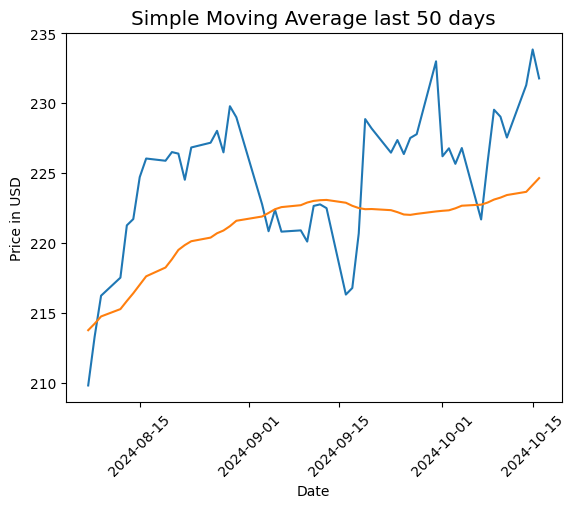

In [13]:
fig, ax = plt.subplots()

# Style Vorlage verwenden
plt.style.use("ggplot")

# Plot für den Schließungspreis:
sns.lineplot(
    data=df.tail(50),
    x="Date",
    y="Close",
    ax=ax
)

# Plot für den SMA:
sns.lineplot(
    data=df.tail(50),
    x="Date",
    y="SMA_50",
    ax=ax
)

ax.set_title("Simple Moving Average last 50 days")
ax.set_ylabel("Price in USD")
ax.tick_params(axis="x", labelrotation=45)


**Der Golden Cross**

Der Golden Cross (Goldenes Kreuz) ist ein bekanntes technisches Analyse-Muster, das als starkes bullisches Signal gilt. Es tritt auf, wenn ein kurzfristiger gleitender Durchschnitt über einen langfristigen gleitenden Durchschnitt kreuzt. Im Kontext der Golden-Cross-Strategie werden häufig der 50-Tage-Simple-Moving-Average (SMA50) und der 200-Tage-Simple-Moving-Average (SMA200) verwendet.
</br>
</br>

Das Golden Cross tritt auf, wenn:

- Der SMA50 von unten nach oben über den SMA200 kreuzt.
- Dies signalisiert einen potenziellen Wechsel von einem Abwärts- zu einem Aufwärtstrend.
- Es wird als starkes bullisches Signal interpretiert, das auf steigende Preise hindeutet.

Phasen des Golden Cross:

- Abwärtstrend: Der Markt befindet sich in einem Abwärtstrend, und der SMA50 liegt unter dem SMA200.
- Trendwende: Der Preis beginnt zu steigen, und der SMA50 nähert sich dem SMA200.
- Kreuzung: Der SMA50 kreuzt den SMA200 von unten nach oben – das eigentliche Golden Cross.
- Aufwärtstrend: Nach der Kreuzung bestätigt ein anhaltender Preisanstieg den neuen Aufwärtstrend.

**Visualisierung des Golden Cross**

In [14]:
# Berechnen der SMA200 Werte:
period = 200
sma_values  = calculate_sma(data=df["Close"], period=period)
sma_padded = np.concatenate(( [np.nan]*(period -1), sma_values ))
df['SMA_200'] = sma_padded

In [15]:
# Überprüfen der Daten:
df.tail(10)

,Open,High,Low,Close,Adj Close,Volume,SMA_50,SMA_200
Date,,,,,,,,
2024-10-03,225.139999,226.809998,223.320007,225.669998,225.669998,34044200,222.488601,197.79760
2024-10-04,227.899994,228.000000,224.130005,226.800003,226.800003,37245100,222.674801,197.95215
2024-10-07,224.500000,225.690002,221.330002,221.690002,221.690002,39505400,222.749401,198.07590
2024-10-08,224.300003,225.979996,223.250000,225.770004,225.770004,31855700,222.900001,198.23060
2024-10-09,225.229996,229.750000,224.830002,229.539993,229.539993,33591100,223.114800,198.40490
2024-10-10,227.779999,229.500000,227.169998,229.039993,229.039993,28183500,223.254000,198.58210
2024-10-11,229.300003,229.410004,227.339996,227.550003,227.550003,31759200,223.437800,198.75460
2024-10-14,228.699997,231.729996,228.600006,231.300003,231.300003,39882100,223.666600,198.94535
2024-10-15,233.610001,237.490005,232.369995,233.850006,233.850006,64751400,224.158200,199.14670


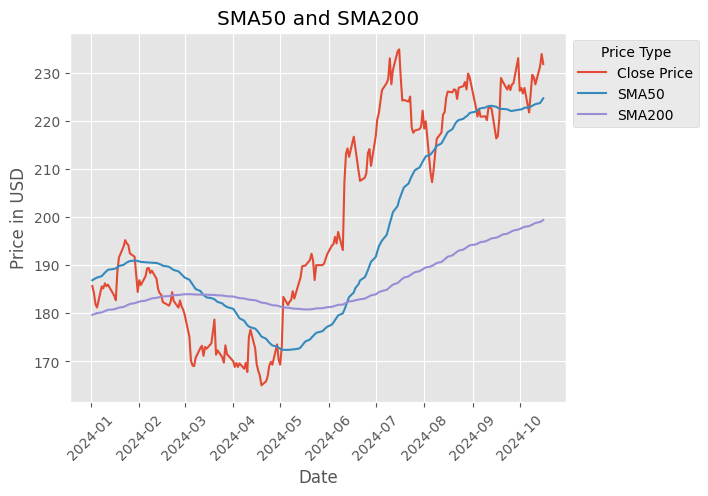

In [16]:
fig1, ax1 = plt.subplots()

# Style Vorlage verwenden
plt.style.use("ggplot")

# Plot für den Schließungspreis:
sns.lineplot(
    data=df.tail(200),
    x="Date",
    y="Close",
    label="Close Price",
    ax=ax1
)

# Plot für den SMA50:
sns.lineplot(
    data=df.tail(200),
    x="Date",
    y="SMA_50",
    label="SMA50",
    ax=ax1
)

# Plot für den SMA200:
sns.lineplot(
    data=df.tail(200),
    x="Date",
    y="SMA_200",
    label="SMA200",
    ax=ax1
)

ax1.set_title("SMA50 and SMA200")
ax1.set_ylabel("Price in USD")
ax1.tick_params(axis="x", labelrotation=45)
ax1.legend(title="Price Type", bbox_to_anchor=(1, 1)) # Legende außerhalb des Plots platzieren


Um diese Kreuzungen zu identifizieren, können wir die Differenz der beiden SMAs betrachten und prüfen, wo diese Differenz von negativ zu positiv wechselt:

In [17]:
# Berechnung der Differenz zwischen SMA50 und SMA200:
df['SMA_Diff'] = df['SMA_50'] - df['SMA_200']

# Erstellen einer Spalte welche den Golden Cross signalisiert:
df['Signal'] = 0

# Identifikation des Golden Cross (von unten nach oben):
df.loc[(df['SMA_Diff'].shift(1) < 0) & (df['SMA_Diff'] > 0), 'Signal'] = 1 # shift(1) Verschiebt die Daten um einen Tag, um den Vergleich zwischen aufeinanderfolgenden Tagen zu ermöglichen.

# Identifikation des Death Cross (von oben nach unten):
df.loc[(df['SMA_Diff'].shift(1) > 0) & (df['SMA_Diff'] < 0), 'Signal'] = -1

df

,Open,High,Low,Close,Adj Close,Volume,SMA_50,SMA_200,SMA_Diff,Signal
Date,,,,,,,,,,
2018-01-02,42.540001,43.075001,42.314999,43.064999,40.568928,102223600,NaN,NaN,NaN,0
2018-01-03,43.132500,43.637501,42.990002,43.057499,40.561863,118071600,NaN,NaN,NaN,0
2018-01-04,43.134998,43.367500,43.020000,43.257500,40.750271,89738400,NaN,NaN,NaN,0
2018-01-05,43.360001,43.842499,43.262501,43.750000,41.214237,94640000,NaN,NaN,NaN,0
2018-01-08,43.587502,43.902500,43.482498,43.587502,41.061150,82271200,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...
2024-10-10,227.779999,229.500000,227.169998,229.039993,229.039993,28183500,223.2540,198.58210,24.671900,0
2024-10-11,229.300003,229.410004,227.339996,227.550003,227.550003,31759200,223.4378,198.75460,24.683200,0
2024-10-14,228.699997,231.729996,228.600006,231.300003,231.300003,39882100,223.6666,198.94535,24.721250,0


In [18]:
# Die jeweiligen Zeilen ausgeben (# im Jahr 2024 gab es 2 Überschneidungen):
signals = df[df['Signal'] != 0]
signals

,Open,High,Low,Close,Adj Close,Volume,SMA_50,SMA_200,SMA_Diff,Signal
Date,,,,,,,,,,
2018-12-20,40.099998,40.527500,38.825001,39.207500,37.489529,259092000,48.500400,48.510725,-0.010325,-1
2019-05-07,51.470001,51.855000,50.207500,50.715000,48.700771,155054800,48.125600,48.102713,0.022887,1
2022-06-03,146.899994,147.970001,144.460007,145.380005,143.587433,88570300,159.089801,159.486850,-0.397050,-1
2022-09-28,147.639999,150.639999,144.839996,149.839996,148.197998,146691400,160.288400,160.208600,0.079799,1
2022-09-30,141.279999,143.100006,138.000000,138.199997,136.685532,124925300,159.734200,159.861650,-0.127451,-1
2023-03-23,158.830002,161.550003,157.679993,158.929993,157.689529,67622100,148.340200,147.882600,0.457600,1
2024-03-13,172.770004,173.190002,170.759995,171.130005,170.700623,52488700,183.771199,183.870250,-0.099051,-1
2024-06-13,214.740005,216.750000,211.600006,214.240005,213.992310,97862700,182.485400,182.282400,0.203000,1


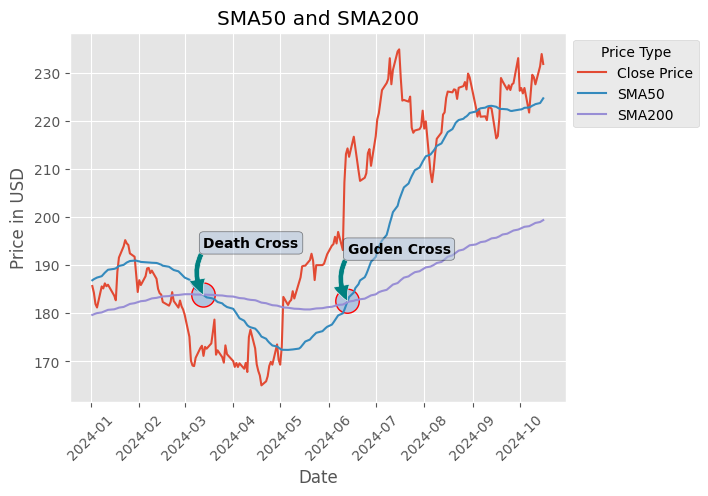

In [19]:
import matplotlib.patches as patches

# Annotieren der Golden Cross
for idx, row in df.iterrows():
    # in "idx" ist das Datum
    if row["Signal"] == 1:
        ax1.annotate(
            "Golden Cross",
            xy=(idx, row["SMA_50"]),
            xytext=(idx, row["SMA_50"] + 10),
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="lightsteelblue", alpha=0.5),
            arrowprops=dict(
                facecolor="teal",
                connectionstyle="arc3,rad=0.3"
            )
        )
        
        circle = patches.Ellipse(
            (idx, row["SMA_50"]), 
            width=15, 
            height=5, 
            edgecolor="red",
            facecolor="lightsteelblue",
            lw=1
        )
        ax1.add_patch(circle)
    
    # Annotieren der Death Cross
    if row["Signal"] == -1:
        ax1.annotate(
            "Death Cross",
            xy=(idx, row["SMA_50"]),
            xytext=(idx, row["SMA_50"] + 10),
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="lightsteelblue", alpha=0.5),
            arrowprops=dict(
                facecolor="teal",
                connectionstyle="arc3,rad=0.3"
            )
        )
        
        circle = patches.Ellipse(
            (idx, row["SMA_50"]), 
            width=15, 
            height=5, 
            edgecolor="red",
            facecolor="lightsteelblue",
            lw=1
        )
        ax1.add_patch(circle)

fig1

## Berechnung des Relative Strength Index (RSI)

Der Relative Strength Index (RSI) ist ein Momentum-Indikator in der technischen Analyse, der die Geschwindigkeit und Veränderung von Preisbewegungen misst. Der RSI schwankt zwischen 0 und 100 und wird verwendet, um überkaufte und überverkaufte Marktbedingungen zu identifizieren.

**Berechnung:**

$$RSI=100-\frac{100}{1+RS}$$

mit: $RS=\frac{\text{Durchschnittlicher Gewinn}}{Durchschnittlicher Verlust}$

****

1. Preisänderung berechnen: Es wird die Differenz zwischen den aufeinanderfolgenden Schlusskursen berechnet. Dabei werden Positive Preisänderungen als Gewinne betrachtet, während negative Preisänderungen als Verluste gelten.
$$\Delta\text{Preis}=\text{Schlusskurs heute}-\text{Schlusskurs gestern}$$ 
2. Gewinne und Verluste isolieren: Gewinne und Verluste werden getrennt z.B. durch eine seperate Spalte
3. Durchschnittliche Gewinne und Verluste berechnen: Dies geschieht über einen bestimmten Zeitraum, in der Regel 14 Tage. Die Formel für den gleitenden Durchschnitt lautet:
$$\text{Durchschnittlicher Gewinn}=\frac{\text{Summe der Gewinne im Zeitraum}}{\text{Zeitraum}}$$
$$\text{Durchschnittlicher Verlust}=\frac{\text{Summe der Verluste im Zeitraum}}{\text{Zeitraum}}$$
4. Relative Stärke: Berechnen des Verhältnisses durchschnittlichen Gewinns zum durchschnittlichen Verlust:
$$\text{RS}=\frac{\text{Durchschnittlicher Gewinn}}{\text{Durchschnittlicher Verlust}}$$
5. Berechnung des RSI: Es wird ein Wert zwischen 0 und 100 aus gegeben.
$$RSI=100-\frac{100}{1+RS}$$

****

**Beispielhafte Berechnung:**

Nehmen wir an, wir haben folgende Schlusskurse über 6 Tage:
- Tag 1: 44
- Tag 2: 46
- Tag 3: 45
- Tag 4: 48
- Tag 5: 47
- Tag 6: 49

1. Preisänderungen berechnen:
   1. Tag 2: $46-44=2$
   2. Tag 3: $45-46=-1$
   3. Tag 4: $48-45=3$
   4. Tag 5: $47-48=-1$
   5. Tag 6: $49-47=2$

2. Gewinne und Verluste isolieren: Die Nullen in den Listen der Gewinne und Verluste entstehen, weil an manchen Tagen keine Gewinne oder keine Verluste auftreten. Lassen Sie uns dies im Detail erklären.
   1. $\text{Gewinne}=2, 0, 3, 0, 2$
   2. $\text{Verluste}=0, -1, 0, -1, 0$
3. Durchschnittliche Gewinne und Verluste (über 5 Tage):
   1. $\text{Durchschnittlicher Gewinn}=\frac{2+3+2}{5}=1.4$
   2. $\text{Durchschnittlicher Verlust}=\frac{1+1}{5}=0.4$
4. RS berechnen:
   1. $\text{RS}=\frac{1.4}{0.4}=3.5$
5. RSI berechnen:
   1. $RSI=100-\frac{100}{1+3.5}\approx77.78$

Der RSI für diese 6-Tage-Periode wäre etwa 77.78, was darauf hinweist, dass der Markt in einer überkauften Phase sein könnte.

**Berechnung mit Python:**

In [20]:
# Schlusskurse
prices = np.array([44, 46, 45, 48, 47, 49])

# Preisänderungen berechnen
price_changes = np.diff(prices)

price_changes

array([ 2, -1,  3, -1,  2])

In [21]:
# Gewinne und Verluste isolieren
gains = np.where(price_changes > 0, price_changes, 0) # "where" wählt Elemente basierend auf Bedingungen aus, im Array "price_changes"
losses = np.where(price_changes < 0, -price_changes, 0)

print(f"gains={gains}")
print(f"losses={losses}")


gains=[2 0 3 0 2]
losses=[0 1 0 1 0]


In [22]:
# Durchschnittliche Gewinne und Verluste (über 5 Tage)
avg_gain = np.mean(gains)
avg_loss = np.mean(losses)

print(f"avg_gain={avg_gain}")
print(f"avg_loss={avg_loss}")

avg_gain=1.4
avg_loss=0.4


In [23]:
# Relative Stärke (RS)
rs = avg_gain / avg_loss

print(f"rs={rs}")

rs=3.4999999999999996


In [24]:
# RSI berechnen
rsi = 100 - (100 / (1 + rs))

print(f"RSI: {rsi:.2f}")

RSI: 77.78


In [25]:
def calculate_rsi(prices, window=14):
    """
    Berechnet den RSI (Relative Strength Index).
    
    :param prices: Liste oder Array der Schlusskurse.
    :param window: Der Zeitraum, über den der RSI berechnet wird (Standard ist 14 Tage).
    :return: Array mit RSI-Werten.
    """
    # Überprüfen, ob genügend Datenpunkte für das angegebene Fenster vorhanden sind:
    if len(prices) < window:
        raise ValueError("Zu wenige Datenpunkte für das angegebene Fenster.")

    # 1. Preisänderungen berechnen:
    price_changes = np.diff(prices)

    # 2. Gewinne und Verluste isolieren:
    gains = np.where(price_changes > 0, price_changes, 0) # nur positive Änderungen oder 0
    losses = np.where(price_changes < 0, -price_changes, 0) # absoluten Werte der negativen Änderungen oder 0

    # 3. Durchschnittliche Gewinne und Verluste berechnen
    avg_gain = np.zeros(len(prices), dtype=float)
    avg_loss = np.zeros(len(prices), dtype=float)

    # Berechnung des initialen Durchschnitts für das erste Fenster:
    avg_gain[window - 1] = np.mean(gains[:window])
    avg_loss[window - 1] = np.mean(losses[:window])

    # 4. RSI-Array initialisieren
    rsi = np.zeros(len(prices), dtype=float)
    rsi[:window - 1] = np.nan  # Vor dem initialen Fenster gibt es keine RSI-Werte

    # 5. RSI für das initiale Fenster berechnen
    with np.errstate(divide="ignore", invalid="ignore"):
        rs = avg_gain[window - 1] / avg_loss[window - 1]
    rsi[window - 1] = 100 - (100 / (1 + rs))

    # 6. RSI schrittweise für den restlichen Zeitraum berechnen:
    for i in range(window, len(prices)):
        avg_gain[i] = (avg_gain[i - 1] * (window - 1) + gains[i - 1]) / window
        avg_loss[i] = (avg_loss[i - 1] * (window - 1) + losses[i - 1]) / window

        # Relative Stärke (RS) für den aktuellen Tag berechnen:
        # Innerhalb dieses with-Blocks keine Warnungen oder Fehler ausgegeben werden, 
        # wenn eine Division durch Null oder eine ungültige Operation auftritt.
        with np.errstate(divide="ignore", invalid="ignore"): # ändert temporär die Fehlerbehandlung für Division durch Null
            rs = avg_gain[i] / avg_loss[i]
        # RSI für den aktuellen Tag berechnen:
        rsi[i] = 100 - (100 / (1 + rs))

    return rsi

# Testen der Funktion:
prices = np.array([44, 46, 45, 48, 47, 49])

# Mit einem kleineren Fenster testen
rsi_values = calculate_rsi(prices, window=5)
print(rsi_values)


[        nan         nan         nan         nan 77.77777778 82.60869565]


In [ ]:
df['RSI_14'] = calculate_rsi(df['Close'], window=14)
df.head(15)

,Open,High,Low,Close,Adj Close,Volume,SMA_50,SMA_200,SMA_Diff,Signal,RSI_14
Date,,,,,,,,,,,
2018-01-02,42.540001,43.075001,42.314999,43.064999,40.568928,102223600,NaN,NaN,NaN,0,NaN
2018-01-03,43.132500,43.637501,42.990002,43.057499,40.561863,118071600,NaN,NaN,NaN,0,NaN
2018-01-04,43.134998,43.367500,43.020000,43.257500,40.750271,89738400,NaN,NaN,NaN,0,NaN
2018-01-05,43.360001,43.842499,43.262501,43.750000,41.214237,94640000,NaN,NaN,NaN,0,NaN
2018-01-08,43.587502,43.902500,43.482498,43.587502,41.061150,82271200,NaN,NaN,NaN,0,NaN
2018-01-09,43.637501,43.764999,43.352501,43.582500,41.056435,86336000,NaN,NaN,NaN,0,NaN
2018-01-10,43.290001,43.575001,43.250000,43.572498,41.047020,95839600,NaN,NaN,NaN,0,NaN
2018-01-11,43.647499,43.872501,43.622501,43.820000,41.280163,74670800,NaN,NaN,NaN,0,NaN
2018-01-12,44.044998,44.340000,43.912498,44.272499,41.706436,101672400,NaN,NaN,NaN,0,NaN


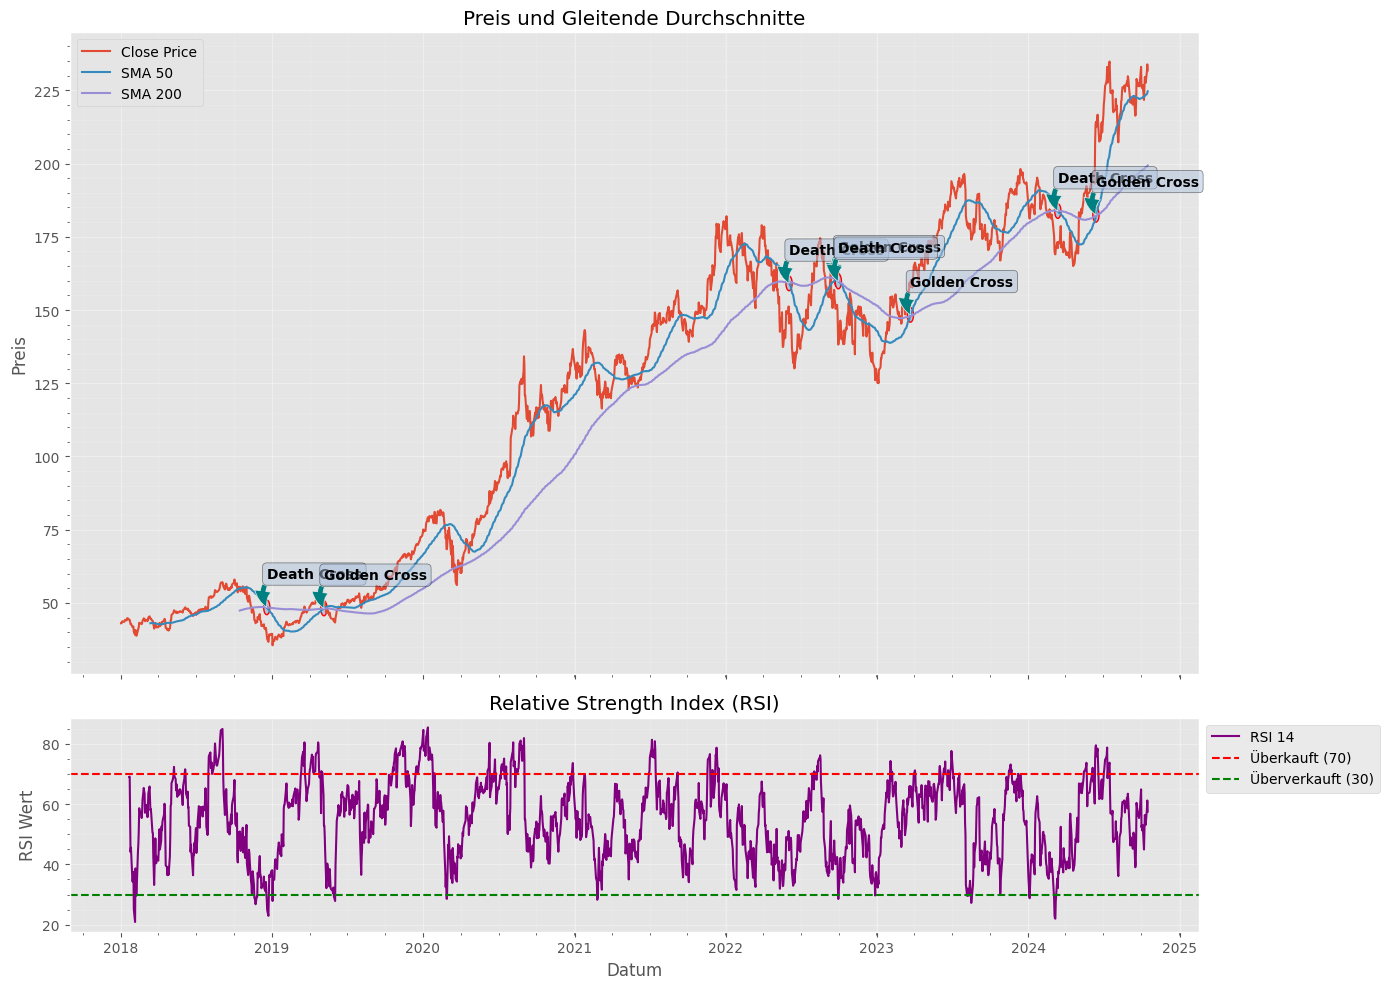

In [27]:
# Erstellen Sie eine Figur mit zwei Subplots und geteilten x-Achsen
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1]}) # "gridspec_kw" oberer plot ist 3 mal so hoch wie der untere Plot

# Close Price
ax1.plot(
    df.index,
    df["Close"],
    label="Close Price",
)
# SMA50
ax1.plot(
    df.index,
    df["SMA_50"],
    label="SMA 50",
)
# SMA200
ax1.plot(
    df.index,
    df["SMA_200"],
    label="SMA 200",
)

# Annotieren der Golden Cross und Death Cross
for idx, row in df.iterrows():
    # in "idx" ist das Datum
    if row["Signal"] == 1:
        ax1.annotate(
            "Golden Cross",
            xy=(idx, row["SMA_50"]),
            xytext=(idx, row["SMA_50"] + 10),
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.3",
                edgecolor="black",
                facecolor="lightsteelblue",
                alpha=0.5
            ),
            arrowprops=dict(
                facecolor="teal",
                connectionstyle="arc3,rad=0.3"
            )
        )
        circle = patches.Ellipse(
            (idx, row["SMA_50"]),
            width=15,
            height=5,
            edgecolor="red",
            facecolor="lightsteelblue",
            lw=1
        )
        ax1.add_patch(circle)
    
    # Annotieren der Death Cross
    if row["Signal"] == -1:
        ax1.annotate(
            "Death Cross",
            xy=(idx, row["SMA_50"]),
            xytext=(idx, row["SMA_50"] + 10),
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.3",
                edgecolor="black",
                facecolor="lightsteelblue",
                alpha=0.5
            ),
            arrowprops=dict(
                facecolor="teal",
                connectionstyle="arc3,rad=0.3"
            )
        )
        circle = patches.Ellipse(
            (idx, row["SMA_50"]),
            width=15,
            height=5,
            edgecolor="red",
            facecolor="lightsteelblue",
            lw=1
        )
        ax1.add_patch(circle)

# Einstellungen für das obere Diagramm
ax1.set_title("Preis und Gleitende Durchschnitte")
ax1.set_ylabel("Preis")
ax1.legend()
ax1.grid(True)

# Plotten des RSI im unteren Subplot
ax2.plot(df.index, df["RSI_14"], label="RSI 14", color="purple")
ax2.axhline(70, color="red", linestyle="--", label="Überkauft (70)")
ax2.axhline(30, color="green", linestyle="--", label="Überverkauft (30)")
ax2.set_title("Relative Strength Index (RSI)")
ax2.set_xlabel("Datum")
ax2.set_ylabel("RSI Wert")
ax2.legend()
ax2.grid(True)

# Zusätzliche ticks einfügen
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())

# Grid einfügen
ax1.grid(which='both', linestyle='-', linewidth=0.5)
ax1.grid(which='minor', alpha=0.2)  # Feinere Linien für Minor Gridlines
ax1.grid(which='major', alpha=0.5)  # Deutlichere Linien für Major Gridlines

# Zusätzliche ticks einfügen
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax2.yaxis.set_minor_locator(AutoMinorLocator())

# Grid einfügen
ax2.grid(which='both', linestyle='-', linewidth=0.5)
ax2.grid(which='minor', alpha=0.2)
ax2.grid(which='major', alpha=0.5)

ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
